In [1]:
import os, time

import math
import numpy as np
from numpy.polynomial.hermite import hermgauss
from scipy.optimize import newton

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable 

from skrmt.ensemble.spectral_law import MarchenkoPasturDistribution

# Following options are dependant on https://github.com/chanjure/global_chanju.git
# However, this is just an aesthetic package for plotting, so it is not necessary.
from global_chanju.paulplot.styles import nice_style
from global_chanju.paulplot.rc_setter import set_rc
from global_chanju.paulplot.rc_setter import get_rc
from global_chanju.utils.statistics import asym_err
from global_chanju.utils.statistics import f_bin
from global_chanju.paulplot.styles import base_ten


set_rc() # Setting global chanju plotting scheme

In [2]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=200):
    new_cmap = LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

# -1. Directory setup

In [3]:
plot_dir7 = "../images/2.multi/"
data_dir7 = "../data/2.multi/"

os.system("mkdir -p " + plot_dir7)
os.system("mkdir -p " + data_dir7)

0

# 6. Multilayer

In [4]:
def mu1(sigma_W, sigma_Z, trained=0):
    if trained:
        return sigma_Z**2 / 4 # Trained
    else:
        return sigma_Z**2 / 4. # Untrained

def mu2(sigma_W, sigma_Z, trained=0):
    if trained:
        return sigma_Z**2 * (np.pi*sigma_W - 1) / (2 * np.pi * sigma_W) # Trained
    else:
        return 0.5*sigma_W**2 # Untrained

def epsilon_0_multi(sigma_W, sigma_Z, trained=0):
    return 1./mu2(sigma_W, sigma_Z, trained=trained)

def epsilon_c_multi(sigma_W, sigma_Z, r, trained=0):
    return 1./(mu2(sigma_W, sigma_Z, trained=trained) + mu1(sigma_W, sigma_Z, trained=trained)/(sigma_W * r**(0.25)))

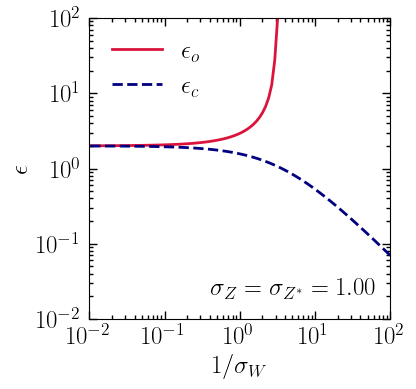

In [5]:
r = 0.5

sigma_list = np.logspace(-2, 2, 100)
sigma_Z = 1.
# sigma_Z = sigma_list

trained = 1

eps_o_range = epsilon_0_multi(sigma_W = sigma_list, sigma_Z = sigma_Z, trained=trained)
eps_c_range = epsilon_c_multi(sigma_W = sigma_list, sigma_Z = sigma_Z, r=r, trained=trained)

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']))

eps_o_val = np.abs(eps_o_range)
cut = 37
axs.plot(1./sigma_list[cut:], eps_o_val[cut:], 
         color='crimson', marker='', ls='-', lw=2,
         label=r"$\epsilon_o$")

axs.plot(1./sigma_list, eps_c_range, 
         color='navy', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$")

nice_style(axs,
           logy=True, logx=True,
           xlim=(1e-2, 1e2), ylim=(1e-2, 1e2),
           xlabel=r"$1/\sigma_W$", ylabel=r"$\epsilon$"
          )

axs.text(0.4, 0.1,
            transform=axs.transAxes,
            horizontalalignment='left', verticalalignment='center',
            color='k', 
#             s=r"$\sigma_Z = \sigma_W$"
#             s=r"$\sigma_Z = %.2f$"%(sigma_Z)
            s=r"$\sigma_Z = \sigma_{Z^{\ast}} = %.2f$"%(sigma_Z)
           )

axs.set_aspect("equal", adjustable="box")

plt.legend()
plt.tight_layout()

plt.savefig(plot_dir7+"multi_phase_boundary_trained.pdf")
plt.show()

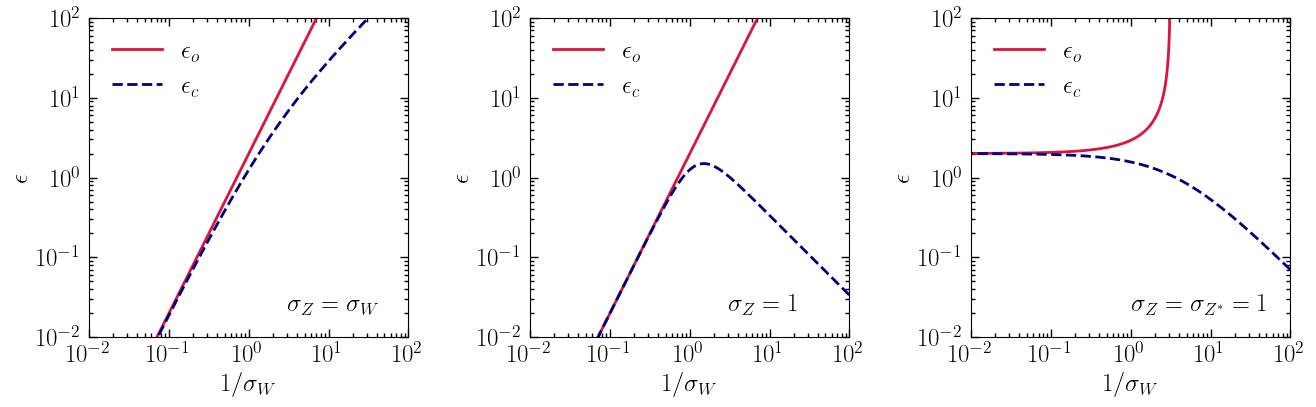

In [22]:
r = 0.5

sigma_list = np.logspace(-2, 2, 500)

n_fig = 3
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']))

# sigma_Z = 1.
sigma_Z = sigma_list
trained = 0

eps_o_range = epsilon_0_multi(sigma_W = sigma_list, sigma_Z = sigma_Z, trained=trained)
eps_c_range = epsilon_c_multi(sigma_W = sigma_list, sigma_Z = sigma_Z, r=r, trained=trained)

eps_o_val = np.where(eps_o_range>0, eps_o_range, np.nan)
# cut = 37
axs[0].plot(
    1./sigma_list, eps_o_val, 
    color='crimson', marker='', ls='-', lw=2,
    label=r"$\epsilon_o$"
)

axs[0].plot(
    1./sigma_list, eps_c_range, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)

nice_style(axs[0],
           logy=True, logx=True,
           xlim=(1e-2, 1e2), ylim=(1e-2, 1e2),
           xlabel=r"$1/\sigma_W$", ylabel=r"$\epsilon$"
          )

axs[0].text(0.62, 0.1,
            transform=axs[0].transAxes,
            horizontalalignment='left', verticalalignment='center',
            color='k', 
            s=r"$\sigma_Z = \sigma_W$"
#             s=r"$\sigma_Z = %.2f$"%(sigma_Z)
#             s=r"$\sigma_Z = \sigma_{Z^{\ast}} = %.2f$"%(sigma_Z)
           )

axs[0].set_aspect("equal", adjustable="box")

#######

sigma_Z = 1.
# sigma_Z = sigma_list
trained = 0

eps_o_range = epsilon_0_multi(sigma_W = sigma_list, sigma_Z = sigma_Z, trained=trained)
eps_c_range = epsilon_c_multi(sigma_W = sigma_list, sigma_Z = sigma_Z, r=r, trained=trained)


eps_o_val = np.where(eps_o_range>0, eps_o_range, np.nan)
# cut = 37
axs[1].plot(
    1./sigma_list, eps_o_val, 
    color='crimson', marker='', ls='-', lw=2,
    label=r"$\epsilon_o$"
)

axs[1].plot(
    1./sigma_list, eps_c_range, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)

nice_style(axs[1],
           logy=True, logx=True,
           xlim=(1e-2, 1e2), ylim=(1e-2, 1e2),
           xlabel=r"$1/\sigma_W$", ylabel=r"$\epsilon$"
          )

axs[1].text(0.62, 0.1,
            transform=axs[1].transAxes,
            horizontalalignment='left', verticalalignment='center',
            color='k', 
#             s=r"$\sigma_Z = \sigma_W$"
            s=r"$\sigma_Z = 1$"
#             s=r"$\sigma_Z = \sigma_{Z^{\ast}} = %.2f$"%(sigma_Z)
           )

axs[1].set_aspect("equal", adjustable="box")

#######

sigma_Z = 1.
# sigma_Z = sigma_list
trained = 1

eps_o_range = epsilon_0_multi(sigma_W = sigma_list, sigma_Z = sigma_Z, trained=trained)
eps_c_range = epsilon_c_multi(sigma_W = sigma_list, sigma_Z = sigma_Z, r=r, trained=trained)


eps_o_val = np.where(eps_o_range>0, eps_o_range, np.nan)
# cut = 37
axs[2].plot(
    1./sigma_list, eps_o_val, 
    color='crimson', marker='', ls='-', lw=2,
    label=r"$\epsilon_o$"
)

axs[2].plot(
    1./sigma_list, eps_c_range, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)

nice_style(axs[2],
           logy=True, logx=True,
           xlim=(1e-2, 1e2), ylim=(1e-2, 1e2),
           xlabel=r"$1/\sigma_W$", ylabel=r"$\epsilon$"
          )

axs[2].text(0.5, 0.1,
            transform=axs[2].transAxes,
            horizontalalignment='left', verticalalignment='center',
            color='k', 
#             s=r"$\sigma_Z = \sigma_W$"
#             s=r"$\sigma_Z = 1$"
            s=r"$\sigma_Z = \sigma_{Z^{\ast}} = 1$"
           )

axs[2].set_aspect("equal", adjustable="box")

axs[0].legend(loc='upper left')
axs[1].legend(loc='upper left')
axs[2].legend(loc='upper left')

plt.tight_layout()

plt.savefig(plot_dir7+"multi_phase_boundary_all.pdf")
plt.show()